In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('AI_Impact_on_Jobs_2030.csv')

In [3]:
df.head()

,Employee_ID,Job_Title,Industry,Country,Education_Level,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Remote_Work_Possibility,Average_Salary_USD,Required_Skills,Automation_Level,Job_Growth_2030,Work_Hours_Per_Week,Company_Size,AI_Tool_Usage,Performance_Score,Upskilling_Needed,Job_Satisfaction,Hiring_Trend_2026
0,AIJ-100000,Data Engineer,Healthcare,Japan,PhD,1,0.25,0.78,Yes,207392,"Python, Communication, Deep Learning",Low,3,37,Enterprise,High,2.08,Yes,3.86,Growing
1,AIJ-100001,Healthcare Analyst,Retail,UK,Bachelor,24,0.73,0.33,No,140785,"Deep Learning, Azure, Communication, TensorFlo...",Low,-5,42,Startup,Moderate,4.54,No,4.23,Growing
2,AIJ-100002,HR Specialist,Education,Canada,High School,21,0.80,0.69,Yes,124800,"Kubernetes, Cloud Computing, TensorFlow, SQL, ...",Medium,-5,57,Startup,Low,3.14,No,3.54,Stable
3,AIJ-100003,Cybersecurity Analyst,Government,UK,Bachelor,5,0.29,0.94,No,199878,"Excel, Kubernetes, Prompt Engineering, Leadership",Medium,7,59,Enterprise,High,3.67,No,4.37,Declining
4,AIJ-100004,Healthcare Analyst,Education,UAE,PhD,20,0.11,0.92,No,178682,"SQL, Leadership, TensorFlow, Cybersecurity",Low,6,34,Startup,High,3.68,No,3.99,Stable


In [4]:
df.shape

(3000, 20)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Employee_ID              3000 non-null   object 
 1   Job_Title                3000 non-null   object 
 2   Industry                 3000 non-null   object 
 3   Country                  3000 non-null   object 
 4   Education_Level          3000 non-null   object 
 5   Years_Experience         3000 non-null   int64  
 6   AI_Replacement_Risk      3000 non-null   float64
 7   Future_Demand_Score      3000 non-null   float64
 8   Remote_Work_Possibility  3000 non-null   object 
 9   Average_Salary_USD       3000 non-null   int64  
 10  Required_Skills          3000 non-null   object 
 11  Automation_Level         3000 non-null   object 
 12  Job_Growth_2030          3000 non-null   int64  
 13  Work_Hours_Per_Week      3000 non-null   int64  
 14  Company_Size            

In [6]:
df.describe()

,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Average_Salary_USD,Job_Growth_2030,Work_Hours_Per_Week,Performance_Score,Job_Satisfaction
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,12.383000,0.502910,0.601203,126641.746667,17.238333,44.773333,3.514643,3.026167
std,7.528958,0.261293,0.226674,55405.053057,16.230322,8.926469,0.873375,1.146361
min,0.000000,0.050000,0.200000,30221.000000,-10.000000,30.000000,2.000000,1.000000
25%,6.000000,0.280000,0.420000,77262.000000,3.000000,37.000000,2.760000,2.060000
50%,12.000000,0.500000,0.600000,127660.500000,17.000000,45.000000,3.540000,3.025000
75%,19.000000,0.730000,0.800000,174811.750000,31.000000,52.000000,4.270000,4.010000
max,25.000000,0.950000,0.990000,219998.000000,45.000000,60.000000,5.000000,5.000000


In [7]:
df.columns

Index(['Employee_ID', 'Job_Title', 'Industry', 'Country', 'Education_Level',
       'Years_Experience', 'AI_Replacement_Risk', 'Future_Demand_Score',
       'Remote_Work_Possibility', 'Average_Salary_USD', 'Required_Skills',
       'Automation_Level', 'Job_Growth_2030', 'Work_Hours_Per_Week',
       'Company_Size', 'AI_Tool_Usage', 'Performance_Score',
       'Upskilling_Needed', 'Job_Satisfaction', 'Hiring_Trend_2026'],
      dtype='object')

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

Employee_ID                0
Job_Title                  0
Industry                   0
Country                    0
Education_Level            0
Years_Experience           0
AI_Replacement_Risk        0
Future_Demand_Score        0
Remote_Work_Possibility    0
Average_Salary_USD         0
Required_Skills            0
Automation_Level           0
Job_Growth_2030            0
Work_Hours_Per_Week        0
Company_Size               0
AI_Tool_Usage              0
Performance_Score          0
Upskilling_Needed          0
Job_Satisfaction           0
Hiring_Trend_2026          0
dtype: int64

In [10]:
cat_cols=df.select_dtypes(include='object').columns
for col in cat_cols:
    counts=df[col].nunique()
    print (f"\n The column {col} unique counts is {counts}: \n", df[col].unique())
    print(f"The value counts in {col} is: \n", df[col].value_counts())


 The column Employee_ID unique counts is 3000: 
 ['AIJ-100000' 'AIJ-100001' 'AIJ-100002' ... 'AIJ-102997' 'AIJ-102998'
 'AIJ-102999']
The value counts in Employee_ID is: 
 Employee_ID
AIJ-100000    1
AIJ-102003    1
AIJ-101994    1
AIJ-101995    1
AIJ-101996    1
             ..
AIJ-101002    1
AIJ-101003    1
AIJ-101004    1
AIJ-101005    1
AIJ-102999    1
Name: count, Length: 3000, dtype: int64

 The column Job_Title unique counts is 20: 
 ['Data Engineer' 'Healthcare Analyst' 'HR Specialist'
 'Cybersecurity Analyst' 'Machine Learning Engineer' 'UX Designer'
 'Digital Marketer' 'Robotics Engineer' 'Product Manager'
 'Cloud Architect' 'AI Engineer' 'Teacher' 'IoT Specialist'
 'Blockchain Developer' 'DevOps Engineer' 'Prompt Engineer'
 'Business Analyst' 'Software Developer' 'Financial Analyst'
 'Data Scientist']
The value counts in Job_Title is: 
 Job_Title
Software Developer           164
HR Specialist                163
Cybersecurity Analyst        162
Robotics Engineer            

In [11]:
df['Employee_ID'].value_counts()

Employee_ID
AIJ-100000    1
AIJ-102003    1
AIJ-101994    1
AIJ-101995    1
AIJ-101996    1
             ..
AIJ-101002    1
AIJ-101003    1
AIJ-101004    1
AIJ-101005    1
AIJ-102999    1
Name: count, Length: 3000, dtype: int64

In [12]:
df.drop('Employee_ID',axis=1,inplace=True)

In [13]:
df.head()

,Job_Title,Industry,Country,Education_Level,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Remote_Work_Possibility,Average_Salary_USD,Required_Skills,Automation_Level,Job_Growth_2030,Work_Hours_Per_Week,Company_Size,AI_Tool_Usage,Performance_Score,Upskilling_Needed,Job_Satisfaction,Hiring_Trend_2026
0,Data Engineer,Healthcare,Japan,PhD,1,0.25,0.78,Yes,207392,"Python, Communication, Deep Learning",Low,3,37,Enterprise,High,2.08,Yes,3.86,Growing
1,Healthcare Analyst,Retail,UK,Bachelor,24,0.73,0.33,No,140785,"Deep Learning, Azure, Communication, TensorFlo...",Low,-5,42,Startup,Moderate,4.54,No,4.23,Growing
2,HR Specialist,Education,Canada,High School,21,0.80,0.69,Yes,124800,"Kubernetes, Cloud Computing, TensorFlow, SQL, ...",Medium,-5,57,Startup,Low,3.14,No,3.54,Stable
3,Cybersecurity Analyst,Government,UK,Bachelor,5,0.29,0.94,No,199878,"Excel, Kubernetes, Prompt Engineering, Leadership",Medium,7,59,Enterprise,High,3.67,No,4.37,Declining
4,Healthcare Analyst,Education,UAE,PhD,20,0.11,0.92,No,178682,"SQL, Leadership, TensorFlow, Cybersecurity",Low,6,34,Startup,High,3.68,No,3.99,Stable


In [14]:
cat_cols=df.select_dtypes(include='object').columns
for col in cat_cols:
    counts=df[col].nunique()
    print (f"\n The column {col} unique counts is {counts}: \n", df[col].unique())


 The column Job_Title unique counts is 20: 
 ['Data Engineer' 'Healthcare Analyst' 'HR Specialist'
 'Cybersecurity Analyst' 'Machine Learning Engineer' 'UX Designer'
 'Digital Marketer' 'Robotics Engineer' 'Product Manager'
 'Cloud Architect' 'AI Engineer' 'Teacher' 'IoT Specialist'
 'Blockchain Developer' 'DevOps Engineer' 'Prompt Engineer'
 'Business Analyst' 'Software Developer' 'Financial Analyst'
 'Data Scientist']

 The column Industry unique counts is 10: 
 ['Healthcare' 'Retail' 'Education' 'Government' 'Energy' 'Media'
 'Technology' 'Manufacturing' 'Finance' 'Transportation']

 The column Country unique counts is 10: 
 ['Japan' 'UK' 'Canada' 'UAE' 'Germany' 'Pakistan' 'India' 'Australia'
 'USA' 'Singapore']

 The column Education_Level unique counts is 4: 
 ['PhD' 'Bachelor' 'High School' 'Master']

 The column Remote_Work_Possibility unique counts is 3: 
 ['Yes' 'No' 'Hybrid']

 The column Required_Skills unique counts is 2937: 
 ['Python, Communication, Deep Learning'
 'Dee

In [15]:
df.ndim

2

## Visualization

In [16]:
df['AI_Replacement_Risk']

0       0.25
1       0.73
2       0.80
3       0.29
4       0.11
        ... 
2995    0.62
2996    0.52
2997    0.72
2998    0.82
2999    0.68
Name: AI_Replacement_Risk, Length: 3000, dtype: float64

<Axes: xlabel='AI_Replacement_Risk', ylabel='Count'>

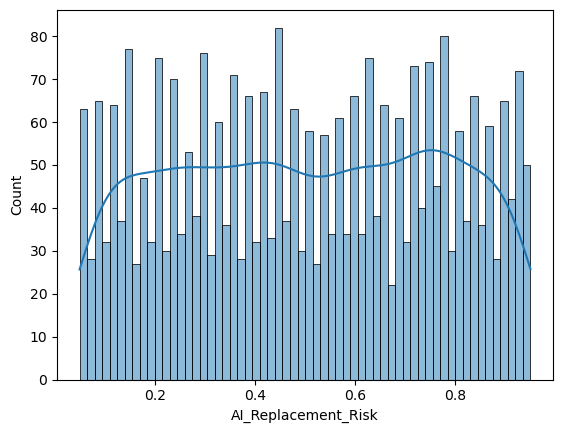

In [17]:
sns.histplot(df['AI_Replacement_Risk'],bins=60,kde=True)

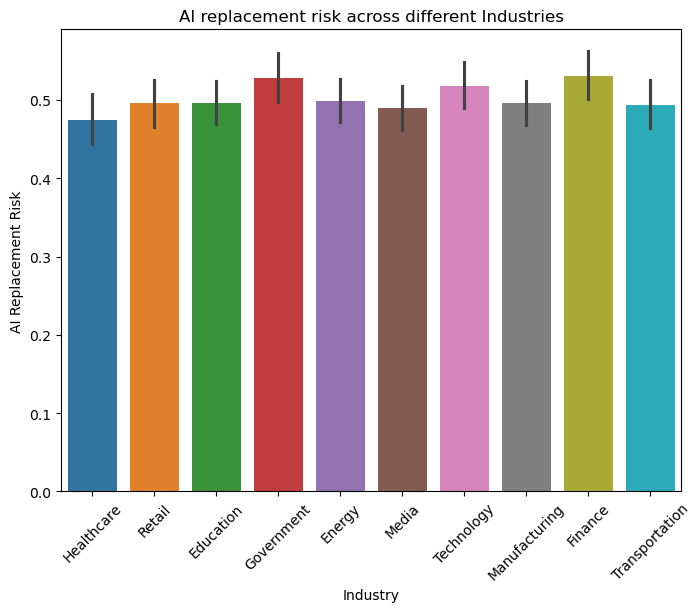

In [18]:
plt.figure(figsize=(8,6))
sns.barplot(df,x='Industry',y='AI_Replacement_Risk',hue='Industry')
plt.xlabel('Industry')
plt.ylabel('AI Replacement Risk')
plt.title('AI replacement risk across different Industries')
plt.xticks(rotation=45)
plt.show()

In [72]:
# Highest industry with AI replacement Risk
AI_replacement_by_industry=df.groupby('Industry')['AI_Replacement_Risk'].aggregate('mean').sort_values(ascending=False)

In [81]:
industry_risk=pd.DataFrame(AI_replacement_by_industry)
industry_risk.reset_index()

,Industry,AI_Replacement_Risk
0,Finance,0.530484
1,Government,0.528793
2,Technology,0.517423
3,Energy,0.499164
4,Education,0.496933
5,Retail,0.496316
6,Manufacturing,0.495875
7,Transportation,0.493754
8,Media,0.489547
9,Healthcare,0.475238


<Figure size 1000x1000 with 0 Axes>

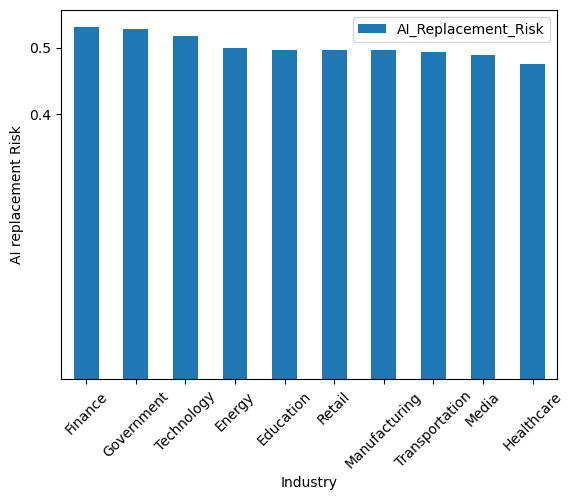

In [129]:
plt.figure(figsize=(10,10))
ax=industry_risk.plot(yticks=[0.4,0.5],kind='bar')
plt.xlabel('Industry')
plt.ylabel('AI replacement Risk')
#plt.xticks(rotation=45)
ax.set_xticks(range(len(industry_risk)))
ax.set_xticklabels(industry_risk.index, rotation=45)
plt.show()

In [124]:
lst=industry_risk['AI_Replacement_Risk'].round(decimals=2).tolist()


In [36]:
education_data=df[df['Industry']=='Education']

In [46]:
education_data.to_csv('education.csv')

In [49]:
education_data.describe()

,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Average_Salary_USD,Job_Growth_2030,Work_Hours_Per_Week,Performance_Score,Job_Satisfaction
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,11.853333,0.496933,0.598833,124409.966667,17.880000,46.016667,3.457767,2.921200
std,7.639789,0.259857,0.221639,55179.413917,15.887742,8.803108,0.913321,1.130565
min,0.000000,0.050000,0.200000,30221.000000,-10.000000,30.000000,2.000000,1.020000
25%,5.750000,0.287500,0.420000,73663.750000,5.000000,38.000000,2.612500,2.005000
50%,12.000000,0.495000,0.590000,126719.500000,17.500000,47.000000,3.485000,2.790000
75%,18.000000,0.730000,0.790000,170663.500000,32.000000,53.000000,4.282500,3.952500
max,25.000000,0.950000,0.990000,218659.000000,45.000000,60.000000,4.980000,4.990000
